In [3]:
from google.colab import files
uploaded = files.upload()

Saving VD_HCC.xlsx to VD_HCC (1).xlsx


# Chọn đặc trưng

In [5]:
import numpy as np
import pandas as pd
# 1. CONFIG: CHỌN ĐẶC TRƯNG
## Chọn 7 đặc trưng được 7/8 kỹ thuật lựa chọn đặc trưng chọn
SELECTED_FEATURES = ['Platelets', 'AST', 'ALT', 'HBsAg',  'AFP', 'APRI', 'FIB-4']
## Chọn 10 đặc trưng được 5/8 kỹ thuật lựa chọn đặc trưng chọn
# SELECTED_FEATURES = ['Platelets', 'AST', 'ALT', 'Total_Bil', 'HBsAg', 'CEA', 'AFP', 'CA19-9', 'APRI', 'FIB-4']
## Nhóm trọng số cao + viêm gan B (Theo chuyên gia)
# SELECTED_FEATURES = ['Age', 'Gender', 'AST', 'ALT', 'AFP', 'HBsAg']
## Nhóm trọng số trung bình + viêm gan B (Theo chuyên gia)
# SELECTED_FEATURES = ['APRI', 'FIB-4', 'AST/ALT', 'HBsAg']
## Học máy 5/8 method + Nhóm trọng số cao (theo chuyên gia)
# SELECTED_FEATURES = ['Platelets', 'AST', 'ALT', 'Total_Bil', 'HBsAg', 'CEA', 'AFP', 'CA19-9', 'APRI', 'FIB-4', 'Age', 'Gender']
## All feature (20 feature)
# SELECTED_FEATURES = ['Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT', 'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose', 'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4']

# 2. LOAD DATA
df = pd.read_excel("VD_HCC.xlsx")

# Chỉ lấy feature đã chọn
X = df[SELECTED_FEATURES]
y = df["label"]

# Tách theo lớp
X_hcc = X[y == 1]
y_hcc = y[y == 1]

X_non = X[y == 0]
y_non = y[y == 0]

# Random Forest (N=30)

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_tr, y_tr)

        # Predict
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:243]],
        X_non.iloc[non_idx[:461]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:243]],
        y_non.iloc[non_idx[:461]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[243:303]],
        X_non.iloc[non_idx[461:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[243:303]],
        y_non.iloc[non_idx[461:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    # print("\n[TRAIN - 10-FOLD CV]")
    # print(f"Accuracy : {train_metrics[0]:.4f}")
    # print(f"Precision: {train_metrics[1]:.4f}")
    # print(f"Recall   : {train_metrics[2]:.4f}")
    # print(f"F1-score : {train_metrics[3]:.4f}")
    # print(f"ROC-AUC  : {train_metrics[4]:.4f}")
    # print(f"PR-AUC   : {train_metrics[5]:.4f}")

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================
    model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    # print("\n[TEST]")
    # print(f"Accuracy : {test_acc:.4f}")
    # print(f"Precision: {test_pre:.4f}")
    # print(f"Recall   : {test_rec:.4f}")
    # print(f"F1-score : {test_f1:.4f}")
    # print(f"ROC-AUC  : {test_auc:.4f}")
    # print(f"PR-AUC   : {test_pr:.4f}")

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS RF================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS RF================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.8938 ± 0.0093
Precision: 0.8708 ± 0.0151
Recall: 0.8172 ± 0.0143
F1-score: 0.8402 ± 0.0140
ROC-AUC: 0.9436 ± 0.0056
PR-AUC: 0.9191 ± 0.0088

---- TEST (Loop N=30) ----
Accuracy: 0.8864 ± 0.0205
Precision: 0.8543 ± 0.0426
Recall: 0.8067 ± 0.0499
F1-score: 0.8284 ± 0.0324
ROC-AUC: 0.9384 ± 0.0178
PR-AUC: 0.9070 ± 0.0271


# XGBoost

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Tính toán trọng số cân bằng cho tập y_tr hiện tại
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

        model = XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric='logloss' # Tránh cảnh báo của phiên bản XGBoost mới
        )

        # Đưa trọng số vào huấn luyện thay cho class_weight="balanced"
        model.fit(X_tr, y_tr, sample_weight=sample_weights)

        # Predict
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:243]],
        X_non.iloc[non_idx[:461]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:243]],
        y_non.iloc[non_idx[:461]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[243:303]],
        X_non.iloc[non_idx[461:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[243:303]],
        y_non.iloc[non_idx[461:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================

    # Tính trọng số cân bằng cho toàn bộ tập y_train
    sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_train)

    model = XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train, sample_weight=sample_weights_full)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

# Đổi tiêu đề thành XGBOOST
print("\n================ FINAL RESULTS XGBOOST ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS XGBOOST ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.8816 ± 0.0078
Precision: 0.8339 ± 0.0147
Recall: 0.8275 ± 0.0133
F1-score: 0.8278 ± 0.0112
ROC-AUC: 0.9321 ± 0.0062
PR-AUC: 0.9010 ± 0.0108

---- TEST (Loop N=30) ----
Accuracy: 0.8767 ± 0.0208
Precision: 0.8222 ± 0.0411
Recall: 0.8183 ± 0.0484
F1-score: 0.8189 ± 0.0303
ROC-AUC: 0.9266 ± 0.0165
PR-AUC: 0.8918 ± 0.0265


# KNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # ---------------------------------------------------------
        # Xử lý missing values (Imputation) và CHUẨN HÓA DỮ LIỆU
        # ---------------------------------------------------------
        imputer = SimpleImputer(strategy='mean') # Sử dụng SimpleImputer để điền giá trị thiếu
        X_tr_imputed = imputer.fit_transform(X_tr)
        X_val_imputed = imputer.transform(X_val)

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_imputed)
        X_val_scaled = scaler.transform(X_val_imputed)

        # Khởi tạo mô hình KNN (Mặc định k=5, bạn có thể tinh chỉnh n_neighbors)
        model = KNeighborsClassifier(n_neighbors=5)

        model.fit(X_tr_scaled, y_tr)

        # Predict (Sử dụng dữ liệu đã chuẩn hóa)
        y_pred = model.predict(X_val_scaled)
        y_prob = model.predict_proba(X_val_scaled)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:243]],
        X_non.iloc[non_idx[:461]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:243]],
        y_non.iloc[non_idx[:461]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[243:303]],
        X_non.iloc[non_idx[461:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[243:303]],
        y_non.iloc[non_idx[461:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================

    # Xử lý missing values trên toàn bộ tập X_train trước khi chuẩn hóa và train
    imputer_full = SimpleImputer(strategy='mean')
    X_train_imputed = imputer_full.fit_transform(X_train)
    X_test_imputed = imputer_full.transform(X_test)

    # Chuẩn hóa lại toàn bộ tập X_train trước khi test
    scaler_full = StandardScaler()
    X_train_scaled = scaler_full.fit_transform(X_train_imputed)

    # Chỉ transform (không fit) trên tập Test
    X_test_scaled = scaler_full.transform(X_test_imputed)

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS KNN ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} \u00b1 {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} \u00b1 {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS KNN ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.8550 ± 0.0086
Precision: 0.8083 ± 0.0146
Recall: 0.7676 ± 0.0178
F1-score: 0.7841 ± 0.0133
ROC-AUC: 0.9000 ± 0.0071
PR-AUC: 0.8210 ± 0.0116

---- TEST (Loop N=30) ----
Accuracy: 0.8574 ± 0.0219
Precision: 0.7988 ± 0.0388
Recall: 0.7794 ± 0.0442
F1-score: 0.7882 ± 0.0337
ROC-AUC: 0.9022 ± 0.0161
PR-AUC: 0.8215 ± 0.0318


# Adaboost

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.impute import SimpleImputer # Import SimpleImputer

# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Xử lý missing values (Imputation)
        imputer = SimpleImputer(strategy='mean')
        X_tr_imputed = imputer.fit_transform(X_tr)
        X_val_imputed = imputer.transform(X_val)

        # Tính toán trọng số cân bằng cho tập y_tr hiện tại
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)

        # Khởi tạo mô hình AdaBoost (Mặc định dùng Decision Stump làm base estimator)
        model = AdaBoostClassifier(
            n_estimators=200,
            random_state=42
        )

        # Đưa trọng số ban đầu vào hàm fit
        model.fit(X_tr_imputed, y_tr, sample_weight=sample_weights)

        # Predict
        y_pred = model.predict(X_val_imputed)
        y_prob = model.predict_proba(X_val_imputed)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:243]],
        X_non.iloc[non_idx[:461]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:243]],
        y_non.iloc[non_idx[:461]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[243:303]],
        X_non.iloc[non_idx[461:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[243:303]],
        y_non.iloc[non_idx[461:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================

    # Xử lý missing values trên toàn bộ tập X_train trước khi huấn luyện
    imputer_full = SimpleImputer(strategy='mean')
    X_train_imputed = imputer_full.fit_transform(X_train)
    X_test_imputed = imputer_full.transform(X_test)

    # Tính trọng số cân bằng cho toàn bộ tập y_train
    sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_train)

    model = AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    )

    # Truyền trọng số vào hàm fit
    model.fit(X_train_imputed, y_train, sample_weight=sample_weights_full)

    y_pred = model.predict(X_test_imputed)
    y_prob = model.predict_proba(X_test_imputed)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS ADABOOST ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS ADABOOST ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.8796 ± 0.0083
Precision: 0.8187 ± 0.0134
Recall: 0.8446 ± 0.0166
F1-score: 0.8288 ± 0.0121
ROC-AUC: 0.9381 ± 0.0068
PR-AUC: 0.9092 ± 0.0097

---- TEST (Loop N=30) ----
Accuracy: 0.8820 ± 0.0193
Precision: 0.8208 ± 0.0410
Recall: 0.8406 ± 0.0432
F1-score: 0.8292 ± 0.0275
ROC-AUC: 0.9375 ± 0.0180
PR-AUC: 0.9111 ± 0.0236


#LightGBM

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Khởi tạo mô hình LightGBM (Hỗ trợ sẵn class_weight="balanced")
        model = LGBMClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            verbose=-1 # Tắt các log cảnh báo của LightGBM trong quá trình train
        )

        model.fit(X_tr, y_tr)

        # Predict
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):

    # print(f"\n========== RUN {run+1} ==========")

    # ---------------- Controlled Sampling ----------------
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:243]],
        X_non.iloc[non_idx[:461]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:243]],
        y_non.iloc[non_idx[:461]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[243:303]],
        X_non.iloc[non_idx[461:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[243:303]],
        y_non.iloc[non_idx[461:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # =====================================================
    # 4.1 K-FOLD TRÊN TRAIN
    # =====================================================
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)

    train_metrics_all.append(train_metrics)

    # =====================================================
    # 4.2 TRAIN FULL MODEL
    # =====================================================
    model = LGBMClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # =====================================================
    # 4.3 TEST METRICS
    # =====================================================
    test_acc = accuracy_score(y_test, y_pred)
    test_pre = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)

    test_auc = roc_auc_score(y_test, y_prob)
    test_pr  = average_precision_score(y_test, y_prob)

    test_metrics_all.append([
        test_acc, test_pre, test_rec, test_f1, test_auc, test_pr
    ])

# =========================================================
# 5. TỔNG HỢP KẾT QUẢ
# =========================================================
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS LIGHTGBM ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS LIGHTGBM ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.8829 ± 0.0105
Precision: 0.8432 ± 0.0189
Recall: 0.8191 ± 0.0165
F1-score: 0.8280 ± 0.0156
ROC-AUC: 0.9357 ± 0.0063
PR-AUC: 0.9094 ± 0.0098

---- TEST (Loop N=30) ----
Accuracy: 0.8775 ± 0.0201
Precision: 0.8287 ± 0.0410
Recall: 0.8111 ± 0.0510
F1-score: 0.8183 ± 0.0305
ROC-AUC: 0.9293 ± 0.0175
PR-AUC: 0.8939 ± 0.0286


#SVM

In [ ]:
# Tính acc, pre, rec, f1, roc, pr-auc cho tập train, test theo features subset =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
# =========================================================
# 3. HÀM K-FOLD TRÊN TRAIN (CÓ ROC-AUC + PR-AUC)
# =========================================================
def kfold_train_evaluate(X_train, y_train, k=10):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    acc_list, pre_list, rec_list, f1_list = [], [], [], []
    auc_list, pr_list = [], []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # ---------------------------------------------------------
        # XỬ LÝ MISSING VALUES VÀ CHUẨN HÓA DỮ LIỆU
        # ---------------------------------------------------------
        imputer = SimpleImputer(strategy='mean')
        X_tr_imputed = imputer.fit_transform(X_tr)
        X_val_imputed = imputer.transform(X_val)

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_imputed)
        X_val_scaled = scaler.transform(X_val_imputed)

        # Khởi tạo mô hình SVM
        model = SVC(
            kernel='rbf',
            class_weight='balanced',
            probability=True,
            random_state=42
        )

        model.fit(X_tr_scaled, y_tr)

        # Predict
        y_pred = model.predict(X_val_scaled)
        y_prob = model.predict_proba(X_val_scaled)[:, 1]

        # Metrics
        acc_list.append(accuracy_score(y_val, y_pred))
        pre_list.append(precision_score(y_val, y_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))

        auc_list.append(roc_auc_score(y_val, y_prob))
        pr_list.append(average_precision_score(y_val, y_prob))

    return (
        np.mean(acc_list),
        np.mean(pre_list),
        np.mean(rec_list),
        np.mean(f1_list),
        np.mean(auc_list),
        np.mean(pr_list)
    )

# =========================================================
# 4. MAIN LOOP (30 RUNS)
# =========================================================
N_RUNS = 30

train_metrics_all = []
test_metrics_all = []

for run in range(N_RUNS):
    hcc_idx = np.random.permutation(len(X_hcc))
    non_idx = np.random.permutation(len(X_non))

    # Train
    X_train = pd.concat([
        X_hcc.iloc[hcc_idx[:243]],
        X_non.iloc[non_idx[:461]]
    ])
    y_train = pd.concat([
        y_hcc.iloc[hcc_idx[:243]],
        y_non.iloc[non_idx[:461]]
    ])

    # Test
    X_test = pd.concat([
        X_hcc.iloc[hcc_idx[243:303]],
        X_non.iloc[non_idx[461:577]]
    ])
    y_test = pd.concat([
        y_hcc.iloc[hcc_idx[243:303]],
        y_non.iloc[non_idx[461:577]]
    ])

    # Shuffle
    idx_train = np.random.permutation(len(X_train))
    idx_test = np.random.permutation(len(X_test))

    X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
    X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

    # 4.1 K-Fold Evaluate
    train_metrics = kfold_train_evaluate(X_train, y_train, k=10)
    train_metrics_all.append(train_metrics)

    # 4.2 Full Model Training with Imputation and Scaling
    imputer_full = SimpleImputer(strategy='mean')
    X_train_imputed = imputer_full.fit_transform(X_train)
    X_test_imputed = imputer_full.transform(X_test)

    scaler_full = StandardScaler()
    X_train_scaled = scaler_full.fit_transform(X_train_imputed)
    X_test_scaled = scaler_full.transform(X_test_imputed)

    model = SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # 4.3 Test Metrics
    test_metrics_all.append([
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob)
    ])

# 5. Result Summary
train_metrics_all = np.array(train_metrics_all)
test_metrics_all = np.array(test_metrics_all)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

print("\n================ FINAL RESULTS SVM ================\n")
print("---- TRAIN (10-FOLD CV) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {train_metrics_all[:, i].mean():.4f} ± {train_metrics_all[:, i].std():.4f}")

print("\n---- TEST (Loop N=30) ----")
for i, name in enumerate(metrics_name):
    print(f"{name}: {test_metrics_all[:, i].mean():.4f} ± {test_metrics_all[:, i].std():.4f}")


================ FINAL RESULTS SVM ================

---- TRAIN (10-FOLD CV) ----
Accuracy: 0.8548 ± 0.0057
Precision: 0.7995 ± 0.0097
Recall: 0.7808 ± 0.0165
F1-score: 0.7867 ± 0.0095
ROC-AUC: 0.9143 ± 0.0063
PR-AUC: 0.8545 ± 0.0121

---- TEST (Loop N=30) ----
Accuracy: 0.8521 ± 0.0206
Precision: 0.7893 ± 0.0345
Recall: 0.7739 ± 0.0469
F1-score: 0.7807 ± 0.0327
ROC-AUC: 0.9126 ± 0.0228
PR-AUC: 0.8428 ± 0.0470


# Vẽ ROC-AUC và PR-AUC

Running: All-features
Running: ML-selected
Running: Expert
Running: ML+Expert


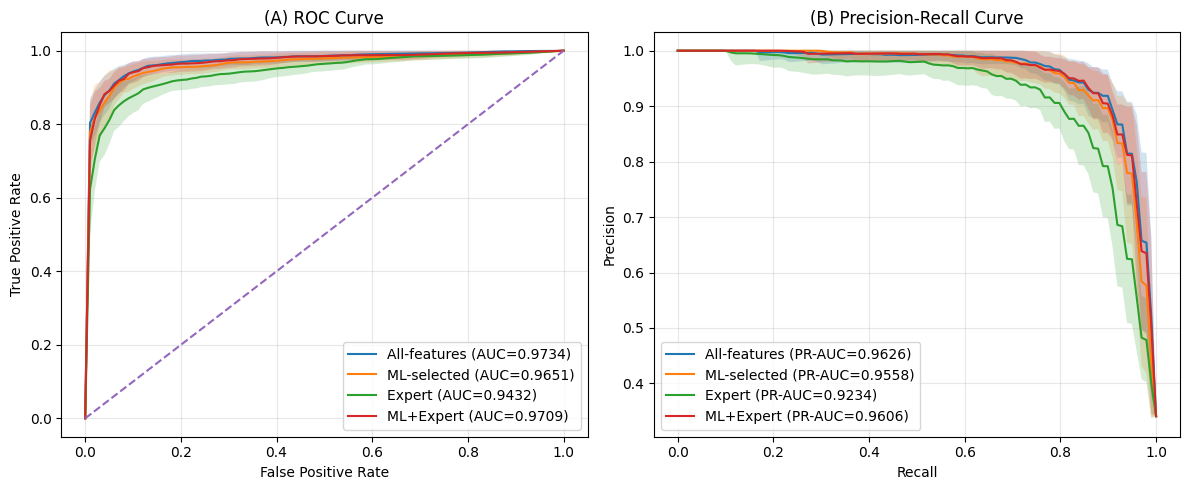

In [ ]:
# Vẽ ROC-AUC, PR-AUC theo các subset =========================================================
# 0. IMPORT
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# =========================================================
# 1. FEATURE SUBSETS
# =========================================================

FEATURE_SETS = {
    "All-features":['Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT', 'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose', 'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4'],
    "ML-selected":['Platelets', 'AST', 'AFP', 'Total_Bil', 'APRI', 'FIB-4', 'HBsAg', 'ALT', 'CEA', 'CA19-9'],
    "Expert":['Age', 'AST', 'AFP', 'Gender', 'ALT', 'HBsAg'],
    "ML+Expert":['Age', 'Platelets', 'AST', 'AFP', 'Total_Bil', 'APRI', 'FIB-4', 'HBsAg', 'ALT', 'Gender', 'CEA', 'CA19-9']
}

# =========================================================
# 2. LOAD DATA
# =========================================================
df = pd.read_excel("VD_HCC.xlsx")
y = df["label"]

# =========================================================
# 3. CONFIG
# =========================================================
N_RUNS = 30
mean_fpr = np.linspace(0, 1, 100)
mean_recall = np.linspace(0, 1, 100)

# =========================================================
# 4. HÀM CHẠY 1 FEATURE SET
# =========================================================
def evaluate_feature_set(feature_list):

    X = df[feature_list]

    X_hcc = X[y == 1]
    X_non = X[y == 0]

    y_hcc = y[y == 1]
    y_non = y[y == 0]

    tprs = []
    prs = []

    aucs = []
    pr_aucs = []

    for run in range(N_RUNS):

        # -------- Controlled Sampling --------
        hcc_idx = np.random.permutation(len(X_hcc))
        non_idx = np.random.permutation(len(X_non))

        # Train
        X_train = pd.concat([
          X_hcc.iloc[hcc_idx[:243]],
          X_non.iloc[non_idx[:461]]
        ])
        y_train = pd.concat([
          y_hcc.iloc[hcc_idx[:243]],
          y_non.iloc[non_idx[:461]]
        ])

        # Test
        X_test = pd.concat([
          X_hcc.iloc[hcc_idx[243:303]],
          X_non.iloc[non_idx[461:577]]
        ])
        y_test = pd.concat([
          y_hcc.iloc[hcc_idx[243:303]],
          y_non.iloc[non_idx[461:577]]
        ])

        # Shuffle
        idx_train = np.random.permutation(len(X_train))
        idx_test = np.random.permutation(len(X_test))

        X_train, y_train = X_train.iloc[idx_train], y_train.iloc[idx_train]
        X_test, y_test = X_test.iloc[idx_test], y_test.iloc[idx_test]

        # -------- Model --------
        model = RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        )
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]

        # -------- ROC --------
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)

        aucs.append(roc_auc_score(y_test, y_prob))

        # -------- PR --------
        precision, recall, _ = precision_recall_curve(y_test, y_prob)

        precision = precision[::-1]
        recall = recall[::-1]

        interp_pr = np.interp(mean_recall, recall, precision)
        prs.append(interp_pr)

        pr_aucs.append(average_precision_score(y_test, y_prob))

    # -------- Mean --------
    return {
        "mean_tpr": np.mean(tprs, axis=0),
        "std_tpr": np.std(tprs, axis=0),
        "mean_pr": np.mean(prs, axis=0),
        "std_pr": np.std(prs, axis=0),
        "auc_mean": np.mean(aucs),
        "auc_std": np.std(aucs),
        "pr_auc_mean": np.mean(pr_aucs),
        "pr_auc_std": np.std(pr_aucs)
    }

# =========================================================
# 5. CHẠY TẤT CẢ FEATURE SETS
# =========================================================
results = {}

for name, features in FEATURE_SETS.items():
    print(f"Running: {name}")
    results[name] = evaluate_feature_set(features)

# =========================================================
# 6. VẼ ROC + PR OVERLAY
# =========================================================
import matplotlib.pyplot as plt

# TẠO FIGURE 2 PANEL
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax_roc = axes[0]
ax_pr = axes[1]

# ROC PANEL
for name, res in results.items():

    mean_tpr = res["mean_tpr"]
    std_tpr = res["std_tpr"]

    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

    ax_roc.plot(
        mean_fpr,
        mean_tpr,
        label=f"{name} (AUC={res['auc_mean']:.4f})"
    )

    ax_roc.fill_between(
        mean_fpr,
        tpr_lower,
        tpr_upper,
        alpha=0.2
    )

# Random baseline
ax_roc.plot([0, 1], [0, 1], '--')

ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("(A) ROC Curve")
ax_roc.legend()
ax_roc.grid(alpha=0.3)

# PR PANEL
for name, res in results.items():

    mean_pr = res["mean_pr"]
    std_pr = res["std_pr"]

    pr_upper = np.minimum(mean_pr + std_pr, 1)
    pr_lower = np.maximum(mean_pr - std_pr, 0)

    ax_pr.plot(
        mean_recall,
        mean_pr,
        label=f"{name} (PR-AUC={res['pr_auc_mean']:.4f})"
    )

    ax_pr.fill_between(
        mean_recall,
        pr_lower,
        pr_upper,
        alpha=0.2
    )

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("(B) Precision-Recall Curve")
ax_pr.legend()
ax_pr.grid(alpha=0.3)

# TỐI ƯU LAYOUT
plt.tight_layout()

# Hiển thị
plt.show()